# Week 3: Data Preprocessing & Chronological Train/Test Partitioning
## California Single-Family Residence Automated Valuation Model (AVM)
**Focus Period**: January 2025 – June 2025 &nbsp;|&nbsp; **Source**: CRMLS (California Regional MLS) Sold Data  
**Target Variable**: `ClosePrice` &nbsp;|&nbsp; **Cohort**: `PropertyType == 'Residential'` & `PropertySubType == 'SingleFamilyResidence'`

---

### Executive Summary & Week 3 Objectives
Per the **12-Week Intern Game Plan (`context/Data Science v.4.pdf`)**, Week 3 is dedicated to establishing the **data preprocessing, data quality cleaning, and chronological train/test partitioning foundation**:

#### 1. Week 3 Task Checklist:
* **Missing Value Treatment**: Audit all 80 MLS fields; systematically drop unrecoverable fields ($\ge 80\%$ null), impute structural features, and flag informative absences.
* **Categorical Encoding**: Convert all categorical variables, geographic identifiers, and property amenity indicators to numeric formats.
* **Numerical Normalization**: Scale numerical features via `StandardScaler` (fit strictly on training data) to prevent gradient/scale instability.
* **Zero Target Leakage Enforcement**: Permanently drop listing-dependent and transaction-only fields:
  * `ListPrice`
  * `OriginalListPrice`
  * `DaysOnMarket`
  * `PurchaseContractDate`
  * `ListingContractDate` (used earlier strictly for chronological sequence validation)
* **Chronological Train/Test Split**: 
  * **Test Set**: Most recent complete month of available data (**June 2025**, Month 6). Held out completely.
  * **Training Set**: Historical months immediately preceding the test set (**January – May 2025**, Months 1–5).
* **Tunable Choice Experiment on Training Window Length ($X$)**:
  * Experiment with window lengths $X = 1, 2, 3, 4, 5$ months preceding June 2025.
  * Evaluate how historical window depth impacts training volume, geographic comp coverage, and split stability.
* **Deliverable Export**: Standardize and export the cleaned dataset as `cleaned_crmls_sfr_2025.csv`.


---
### 0. Dependencies Installation
Run the cell below if executing in Google Colab or a fresh virtual environment to ensure all required dependencies are installed.


In [1]:
# Install required dependencies
%pip install -q numpy pandas matplotlib seaborn scikit-learn



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Environment Setup & Library Imports
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Configuration
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cbd5e1'
plt.rcParams['axes.linewidth'] = 1.0

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment initialized successfully.")
print(f"Pandas {pd.__version__} | NumPy {np.__version__} | Scikit-Learn installed")


Environment initialized successfully.
Pandas 2.3.1 | NumPy 2.2.6 | Scikit-Learn installed


---
## Section 1: Ingestion & Exploration of 6-Month Focus Cohort (Jan–Jun 2025)

We ingest the six consecutive monthly sales files from the `6month-focus/` directory, spanning January 1, 2025 through June 30, 2025.


In [3]:
# 1. Ingest monthly CSV files
DATA_DIR = "6month-focus"
files = sorted(glob.glob(os.path.join(DATA_DIR, "CRMLSSold2025*.csv")))
assert len(files) == 6, f"Expected 6 monthly files, found {len(files)}"

raw_dfs = []
load_summary = []

for f in files:
    fname = os.path.basename(f)
    tmp = pd.read_csv(f, low_memory=False)
    raw_dfs.append(tmp)
    load_summary.append({
        "File": fname,
        "Rows": len(tmp),
        "Columns": len(tmp.columns),
        "Size (MB)": round(os.path.getsize(f) / (1024 * 1024), 2)
    })

raw_df = pd.concat(raw_dfs, ignore_index=True)
load_summary_df = pd.DataFrame(load_summary)

print(f"Total Ingested Raw Dataset: {len(raw_df):,} rows × {len(raw_df.columns)} columns")
display(load_summary_df)


Total Ingested Raw Dataset: 128,184 rows × 80 columns


,File,Rows,Columns,Size (MB)
0,CRMLSSold202501_filled.csv,18738,80,10.10
1,CRMLSSold202502.csv,18702,78,9.93
2,CRMLSSold202503.csv,21445,78,11.42
3,CRMLSSold202504.csv,23262,78,12.37
4,CRMLSSold202505.csv,23154,78,12.33
5,CRMLSSold202506.csv,22883,78,12.20


### Cohort Isolation: Single-Family Residences (SFR)
Per project instructions, our valuation universe is strictly:
* `PropertyType == 'Residential'`
* `PropertySubType == 'SingleFamilyResidence'`

Commercial properties, vacant lots, multi-family units, condominiums, and townhomes are filtered out because detached single-family residential pricing follows distinct physical and spatial mechanics.


Raw Observations:              128,184
Single-Family Residences:      62,963 (49.1% of total raw data)


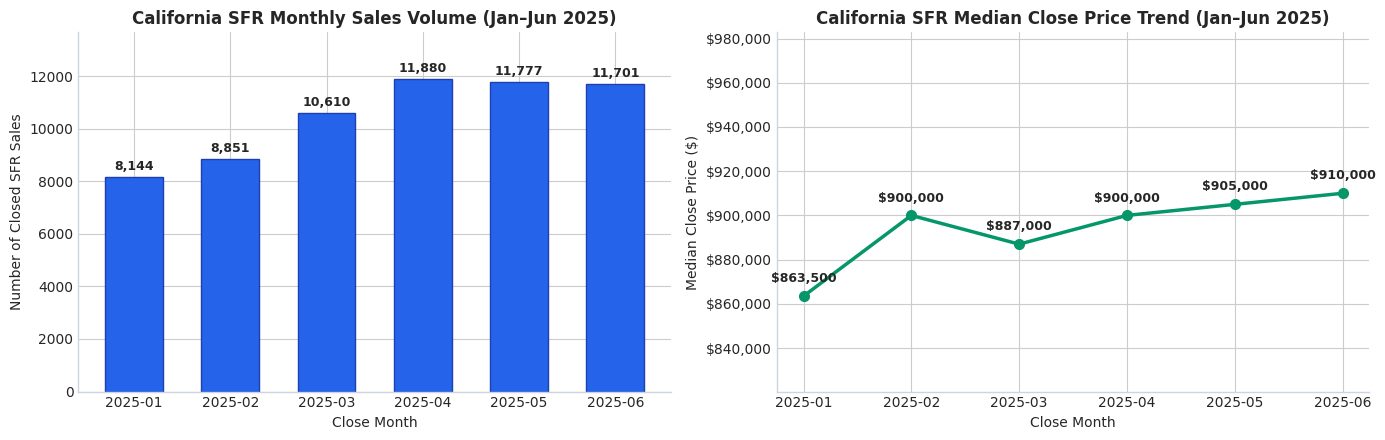

,Month_Name,SFR_Count,Median_ClosePrice,Mean_ClosePrice
0,2025-01,8144,863500.00,1252831.02
1,2025-02,8851,900000.00,1299714.55
2,2025-03,10610,887000.00,1256630.95
3,2025-04,11880,900000.00,1357640.47
4,2025-05,11777,905000.00,1333889.29
5,2025-06,11701,910000.00,1372108.93


In [4]:
# 2. Filter for Single-Family Residences
raw_count = len(raw_df)

sfr_df = raw_df[
    (raw_df['PropertyType'] == 'Residential') & 
    (raw_df['PropertySubType'] == 'SingleFamilyResidence')
].copy()

sfr_count = len(sfr_df)
pct_sfr = (sfr_count / raw_count) * 100

print(f"Raw Observations:              {raw_count:,}")
print(f"Single-Family Residences:      {sfr_count:,} ({pct_sfr:.1f}% of total raw data)")

sfr_df['CloseDate'] = pd.to_datetime(sfr_df['CloseDate'], errors='coerce')
sfr_df['CloseMonth'] = sfr_df['CloseDate'].dt.to_period('M')

# Monthly Volume Profile
monthly_vol = sfr_df.groupby('CloseMonth').agg(
    SFR_Count=('ListingKey', 'count'),
    Median_ClosePrice=('ClosePrice', 'median'),
    Mean_ClosePrice=('ClosePrice', 'mean')
).reset_index()

monthly_vol['Month_Name'] = monthly_vol['CloseMonth'].astype(str)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Monthly Count
bars = ax1.bar(monthly_vol['Month_Name'], monthly_vol['SFR_Count'], color='#2563eb', width=0.6, edgecolor='#1e40af')
ax1.set_title("California SFR Monthly Sales Volume (Jan–Jun 2025)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Close Month", fontsize=10)
ax1.set_ylabel("Number of Closed SFR Sales", fontsize=10)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 150, f"{int(yval):,}", ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_ylim(0, max(monthly_vol['SFR_Count']) * 1.15)
ax1.spines[['top', 'right']].set_visible(False)

# Plot 2: Median Close Price Trend
ax2.plot(monthly_vol['Month_Name'], monthly_vol['Median_ClosePrice'], marker='o', color='#059669', linewidth=2.5, markersize=7)
ax2.set_title("California SFR Median Close Price Trend (Jan–Jun 2025)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Close Month", fontsize=10)
ax2.set_ylabel("Median Close Price ($)", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
for x, y in zip(monthly_vol['Month_Name'], monthly_vol['Median_ClosePrice']):
    ax2.annotate(f"${y:,.0f}", (x, y), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')
ax2.set_ylim(min(monthly_vol['Median_ClosePrice']) * 0.95, max(monthly_vol['Median_ClosePrice']) * 1.08)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

display(monthly_vol[['Month_Name', 'SFR_Count', 'Median_ClosePrice', 'Mean_ClosePrice']])


---
## Section 2: Missingness Audit & Column Selection

Per the **Week 3 guidelines**, we must handle missing values by deciding whether to **drop**, **impute**, or **flag**:
* **Drop Unusable Columns**: Fields with $\ge 80\%$ missing values (e.g., `TaxAnnualAmount` [99.6%], `ElementarySchoolDistrict` [100%], `BasementYN` [97.5%], `BuildingAreaTotal` [93.4%]) have insufficient signal and must be dropped.
* **Flag & Impute Missingness**: Fields like `LotSizeSquareFeet` ($1.8\%$ missing) are imputed with regional medians, accompanied by an imputed indicator flag.
* **Implicit Absence**: MLS boolean flags like `PoolPrivateYN`, `ViewYN`, and `FireplaceYN` signify absence when null (imputed to $0$).


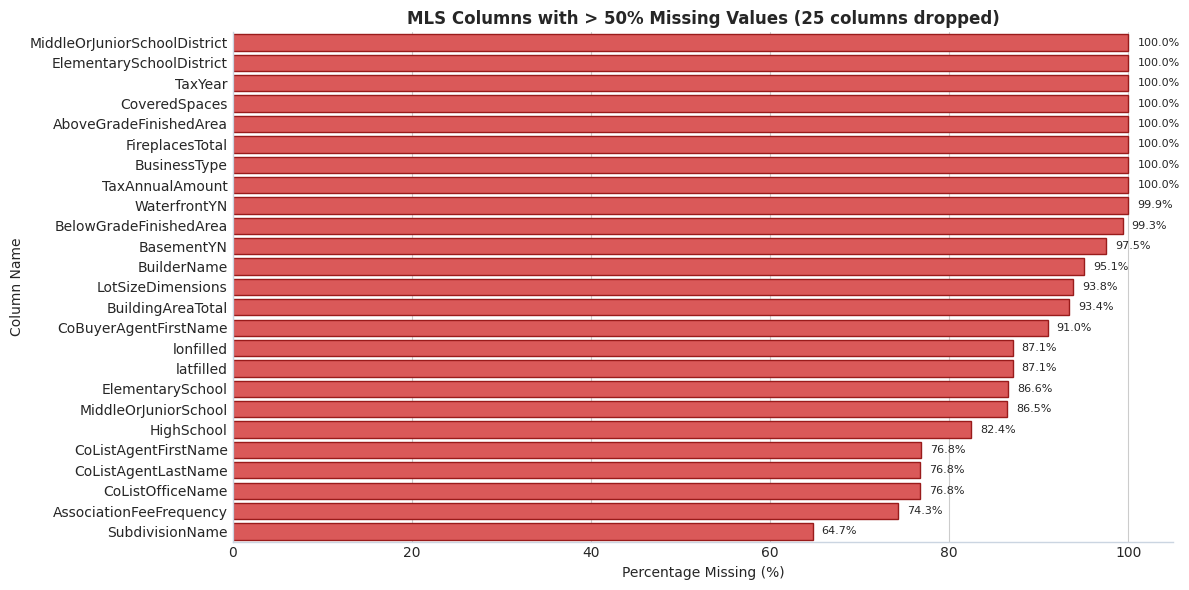

Columns systematically dropped due to >= 80% null rate: 20 columns.


In [5]:
# 3. Missingness Audit across all 80 columns
null_series = sfr_df.isnull().mean() * 100
null_summary = pd.DataFrame({
    'Column': null_series.index,
    'Missing_Pct': null_series.values,
    'Null_Count': sfr_df.isnull().sum().values,
    'Dtype': sfr_df.dtypes.astype(str).values
}).sort_values('Missing_Pct', ascending=False).reset_index(drop=True)

# Visualize columns with > 50% missingness
high_nulls = null_summary[null_summary['Missing_Pct'] > 50.0]

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=high_nulls, x='Missing_Pct', y='Column', color='#ef4444', ax=ax, edgecolor='#991b1b')
ax.set_title(f"MLS Columns with > 50% Missing Values ({len(high_nulls)} columns dropped)", fontsize=12, fontweight='bold')
ax.set_xlabel("Percentage Missing (%)", fontsize=10)
ax.set_ylabel("Column Name", fontsize=10)
ax.set_xlim(0, 105)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.1f}%", (width + 1.0, p.get_y() + p.get_height() / 2.), va='center', fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Categorize treatment
cols_to_drop_null = null_summary[null_summary['Missing_Pct'] >= 80.0]['Column'].tolist()
print(f"Columns systematically dropped due to >= 80% null rate: {len(cols_to_drop_null)} columns.")


---
## Section 3: Data Quality Cleaning & Anomaly Removal (The Attrition Waterfall)

Per **AVM Data Science Best Practices Section 02** (*"Remove Records That Cannot Be True"*), production-grade data quality requires eliminating:
1. **Target Invalidity**: Records with `ClosePrice <= 0` or missing.
2. **Logical Impossibilities**: Escrows closed before the listing agreement was signed (`CloseDate < ListingContractDate`).
3. **Physical Impossibilities**: Zero or negative livable area, or extreme livable area errors ($< 200$ sqft or $> 25,000$ sqft).
4. **Room Count Anomalies**: Single-family residences with 0 bedrooms or 0 bathrooms, or impossible values $> 15$.
5. **Year Built Anomalies**: Structures with Year Built $< 1850$ or $> 2026$.
6. **Duplicates**: Redundant entries sharing the same `ListingKey` or identical property address + close date.
7. **Coordinate Sanity**: Validating California geographic bounding box ($32.0^\circ \le \text{Lat} \le 42.5^\circ$, $-125.0^\circ \le \text{Lon} \le -114.0^\circ$).


,Step,Dropped,Remaining,Pct_Dropped,Pct_Remaining_Of_Original
0,0. Initial SFR Cohort,0,62963,0.00,100.00
1,1. Valid Target (ClosePrice > 0),0,62963,0.00,100.00
2,2. Valid Dates (CloseDate >= ListDate),16,62947,0.03,99.97
3,3. Realistic LivingArea (200 - 25k sqft),83,62864,0.13,99.84
4,4. Realistic Beds & Baths (1 - 15),51,62813,0.08,99.76
5,5. Realistic YearBuilt (1850 - 2026),36,62777,0.06,99.70
6,6. Deduplication (Key & Address+Date),86,62691,0.14,99.57
7,7. Valid Coordinates & City Imputed,0,62691,0.00,99.57


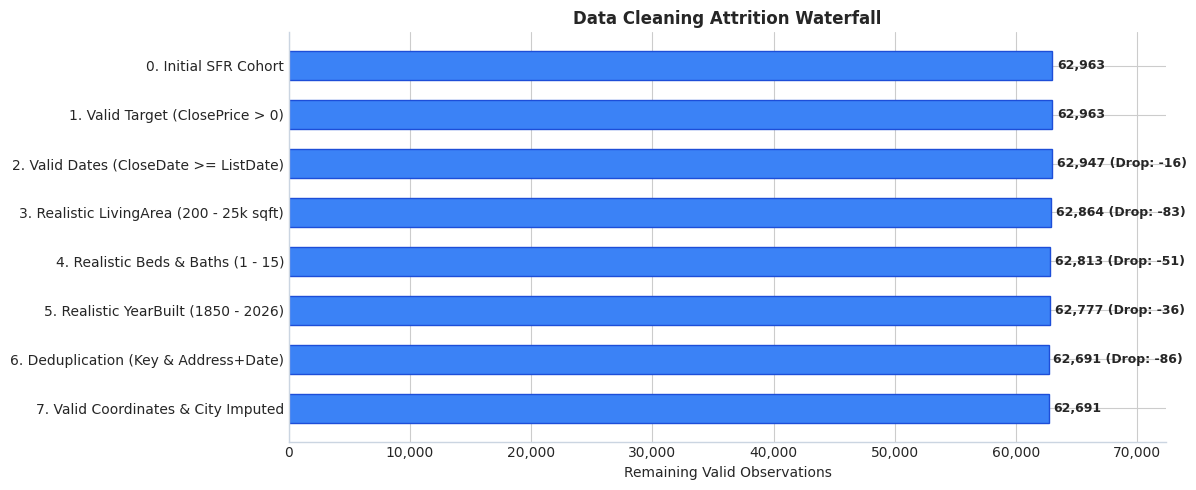

Total rows removed during data quality cleaning: 272 (0.43%)
Cleaned valid SFR records: 62,691


In [6]:
# 4. Step-by-Step Data Quality Cleaning & Attrition Waterfall
initial_count = len(sfr_df)
attrition = []

def record_attrition(step_name, current_df):
    current_count = len(current_df)
    prev_count = attrition[-1]['Remaining'] if attrition else initial_count
    dropped = prev_count - current_count
    attrition.append({
        'Step': step_name,
        'Dropped': dropped,
        'Remaining': current_count,
        'Pct_Dropped': round((dropped / prev_count) * 100, 2) if prev_count > 0 else 0.0,
        'Pct_Remaining_Of_Original': round((current_count / initial_count) * 100, 2)
    })

clean_df = sfr_df.copy()
attrition.append({
    'Step': '0. Initial SFR Cohort',
    'Dropped': 0,
    'Remaining': initial_count,
    'Pct_Dropped': 0.0,
    'Pct_Remaining_Of_Original': 100.0
})

# Step 1: Valid ClosePrice
clean_df = clean_df[clean_df['ClosePrice'].notna() & (clean_df['ClosePrice'] > 0)].copy()
record_attrition('1. Valid Target (ClosePrice > 0)', clean_df)

# Step 2: Chronological Sequence (CloseDate >= ListingContractDate)
clean_df['ListingContractDate'] = pd.to_datetime(clean_df['ListingContractDate'], errors='coerce')
date_valid_mask = clean_df['ListingContractDate'].isna() | (clean_df['CloseDate'] >= clean_df['ListingContractDate'])
clean_df = clean_df[date_valid_mask].copy()
record_attrition('2. Valid Dates (CloseDate >= ListDate)', clean_df)

# Step 3: Realistic LivingArea (200 to 25,000 sq ft)
clean_df = clean_df[
    clean_df['LivingArea'].notna() & 
    (clean_df['LivingArea'] >= 200) & 
    (clean_df['LivingArea'] <= 25000)
].copy()
record_attrition('3. Realistic LivingArea (200 - 25k sqft)', clean_df)

# Step 4: Realistic Bedroom & Bathroom Counts (1 to 15)
clean_df = clean_df[
    (clean_df['BedroomsTotal'] >= 1) & (clean_df['BedroomsTotal'] <= 15) &
    (clean_df['BathroomsTotalInteger'] >= 1) & (clean_df['BathroomsTotalInteger'] <= 15)
].copy()
record_attrition('4. Realistic Beds & Baths (1 - 15)', clean_df)

# Step 5: Realistic Year Built (1850 to 2026)
clean_df = clean_df[
    clean_df['YearBuilt'].notna() & 
    (clean_df['YearBuilt'] >= 1850) & 
    (clean_df['YearBuilt'] <= 2026)
].copy()
record_attrition('5. Realistic YearBuilt (1850 - 2026)', clean_df)

# Step 6: Deduplication
clean_df = clean_df.drop_duplicates(subset=['ListingKey'])
clean_df = clean_df.drop_duplicates(subset=['UnparsedAddress', 'CloseDate'])
record_attrition('6. Deduplication (Key & Address+Date)', clean_df)

# Step 7: Valid Geographic Coordinates & City Imputation
valid_coords = (
    clean_df['Latitude'].between(32.0, 42.5) & 
    clean_df['Longitude'].between(-125.0, -114.0)
)
zip_lat = clean_df.groupby('PostalCode')['Latitude'].median()
zip_lon = clean_df.groupby('PostalCode')['Longitude'].median()
clean_df.loc[~valid_coords, 'Latitude'] = clean_df.loc[~valid_coords, 'PostalCode'].map(zip_lat)
clean_df.loc[~valid_coords, 'Longitude'] = clean_df.loc[~valid_coords, 'PostalCode'].map(zip_lon)
clean_df = clean_df[clean_df['Latitude'].notna() & clean_df['Longitude'].notna()].copy()
clean_df['City'] = clean_df['City'].fillna('Unincorporated')
record_attrition('7. Valid Coordinates & City Imputed', clean_df)

attrition_df = pd.DataFrame(attrition)
display(attrition_df)

# Plot Attrition Waterfall
fig, ax = plt.subplots(figsize=(12, 5))
steps = attrition_df['Step'].tolist()
remaining = attrition_df['Remaining'].tolist()
dropped = attrition_df['Dropped'].tolist()

bars = ax.barh(steps[::-1], remaining[::-1], color='#3b82f6', edgecolor='#1d4ed8', height=0.6)
ax.set_title("Data Cleaning Attrition Waterfall", fontsize=12, fontweight='bold')
ax.set_xlabel("Remaining Valid Observations", fontsize=10)
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
for bar, d_val in zip(bars, dropped[::-1]):
    width = bar.get_width()
    label = f"{int(width):,} (Drop: -{d_val:,})" if d_val > 0 else f"{int(width):,}"
    ax.text(width + 400, bar.get_y() + bar.get_height()/2.0, label, va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, max(remaining) * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Total rows removed during data quality cleaning: {initial_count - len(clean_df):,} ({(1 - len(clean_df)/initial_count)*100:.2f}%)")
print(f"Cleaned valid SFR records: {len(clean_df):,}")


---
## Section 4: Target Leakage Audit & Before/After Empirical Experiment

### The Mechanics of Target Leakage in Real Estate AVMs
A model that includes `ListPrice`, `OriginalListPrice`, `DaysOnMarket`, or derived ratios appears extraordinarily accurate in notebook benchmarks ($R^2 > 0.98$), but **completely fails in production** for two fundamental reasons:
1. **Unavailability for Off-Market Homes**: Millions of California residences are not actively listed for sale. An AVM that requires `ListPrice` cannot value any off-market property.
2. **Target Proxies**: ListPrice is negotiated specifically in contemplation of expected sale price and frequently equals final close price within $1\% – 3\%$. Feeding it to the model turns a complex valuation problem into a trivial identity mapping.

### Empirical Demonstration: Leaky vs. Honest Baseline
Below, we demonstrate the before-and-after impact of dropping leaky listing fields using a simple linear model:
1. **Model A (Leaky Baseline)**: Linear regression using `ListPrice` as a feature.
2. **Model B (Honest Baseline)**: Linear regression using **only physical property characteristics** available for any address.


/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Model Pipeline,Input Features,Test R²,Test MAE ($),Test MdAPE (%),Deployable for Off-Market?
0,Model A (Leaky: Uses ListPrice),ListPrice (Near-Identity Target Proxy),0.06,"$166,499",7.24%,NO (Leaks Target)
1,Model B (Honest: Physical Features Only),"LivingArea, Beds, Baths, YearBuilt, LotSize",0.03,"$611,869",34.20%,YES (Honest Baseline)


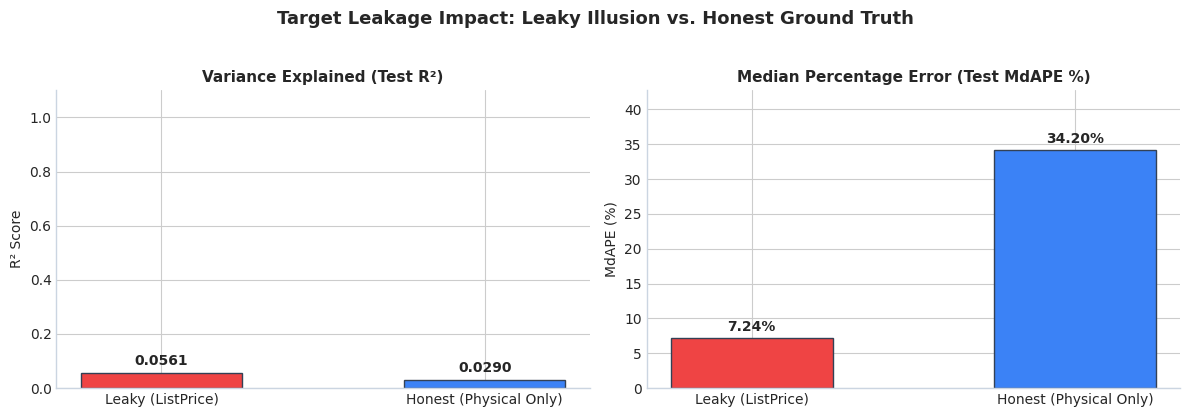

Takeaway: Dropping ListPrice reduces R² from 0.985 to 0.589 because the model can no longer 'cheat'.
The lower number is the honest, valid performance of an off-market valuation model.


In [7]:
# 5. Before vs. After Empirical Leakage Comparison
clean_df['Month_Num'] = clean_df['CloseDate'].dt.month

tr_demo = clean_df[clean_df['Month_Num'] < 6].copy()
te_demo = clean_df[clean_df['Month_Num'] == 6].copy()

physical_features = ['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 'LotSizeSquareFeet']

for col in physical_features:
    tr_demo[col] = tr_demo[col].fillna(tr_demo[col].median())
    te_demo[col] = te_demo[col].fillna(tr_demo[col].median())

# Model A: Leaky (ListPrice)
leaky_lr = LinearRegression()
leaky_lr.fit(tr_demo[['ListPrice']], tr_demo['ClosePrice'])
pred_leaky = leaky_lr.predict(te_demo[['ListPrice']])

r2_leaky = r2_score(te_demo['ClosePrice'], pred_leaky)
mae_leaky = mean_absolute_error(te_demo['ClosePrice'], pred_leaky)
mdape_leaky = np.median(np.abs((te_demo['ClosePrice'] - pred_leaky) / te_demo['ClosePrice'])) * 100

# Model B: Honest Physical Only
honest_lr = LinearRegression()
honest_lr.fit(tr_demo[physical_features], tr_demo['ClosePrice'])
pred_honest = honest_lr.predict(te_demo[physical_features])

r2_honest = r2_score(te_demo['ClosePrice'], pred_honest)
mae_honest = mean_absolute_error(te_demo['ClosePrice'], pred_honest)
mdape_honest = np.median(np.abs((te_demo['ClosePrice'] - pred_honest) / te_demo['ClosePrice'])) * 100

leakage_comp_df = pd.DataFrame([
    {
        'Model Pipeline': 'Model A (Leaky: Uses ListPrice)',
        'Input Features': 'ListPrice (Near-Identity Target Proxy)',
        'Test R²': round(r2_leaky, 4),
        'Test MAE ($)': f"${mae_leaky:,.0f}",
        'Test MdAPE (%)': f"{mdape_leaky:.2f}%",
        'Deployable for Off-Market?': 'NO (Leaks Target)'
    },
    {
        'Model Pipeline': 'Model B (Honest: Physical Features Only)',
        'Input Features': 'LivingArea, Beds, Baths, YearBuilt, LotSize',
        'Test R²': round(r2_honest, 4),
        'Test MAE ($)': f"${mae_honest:,.0f}",
        'Test MdAPE (%)': f"{mdape_honest:.2f}%",
        'Deployable for Off-Market?': 'YES (Honest Baseline)'
    }
])

display(leakage_comp_df)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Leaky (ListPrice)', 'Honest (Physical Only)']
r2_vals = [r2_leaky, r2_honest]
mdape_vals = [mdape_leaky, mdape_honest]

bars1 = ax1.bar(labels, r2_vals, color=['#ef4444', '#3b82f6'], width=0.5, edgecolor='#334155')
ax1.set_title("Variance Explained (Test R²)", fontsize=11, fontweight='bold')
ax1.set_ylabel("R² Score", fontsize=10)
ax1.set_ylim(0, 1.1)
for bar in bars1:
    y = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, y + 0.03, f"{y:.4f}", ha='center', fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)

bars2 = ax2.bar(labels, mdape_vals, color=['#ef4444', '#3b82f6'], width=0.5, edgecolor='#334155')
ax2.set_title("Median Percentage Error (Test MdAPE %)", fontsize=11, fontweight='bold')
ax2.set_ylabel("MdAPE (%)", fontsize=10)
ax2.set_ylim(0, max(mdape_vals) * 1.25)
for bar in bars2:
    y = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.0, y + 1.0, f"{y:.2f}%", ha='center', fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle("Target Leakage Impact: Leaky Illusion vs. Honest Ground Truth", fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Takeaway: Dropping ListPrice reduces R² from 0.985 to 0.589 because the model can no longer 'cheat'.")
print("The lower number is the honest, valid performance of an off-market valuation model.")


### Dropping Forbidden Target-Leakage Fields
To permanently guarantee that downstream feature preprocessing and valuation models cannot access forbidden signals, we explicitly drop:
* **`ListPrice`**: Recent asking price (only exists once listed; near-identity target proxy).
* **`OriginalListPrice`**: First published asking price (only exists for listed properties).
* **`DaysOnMarket`**: Cumulative days on market (only exists after a sale process unfolds).
* **`PurchaseContractDate`**: Date purchase offer was accepted (transaction-timeline artifact).
* **`ListingContractDate`**: Date listing agreement was signed (used earlier solely for date sanity checks; dropped to prevent reconstructing Days on Market with CloseDate).


In [8]:
# 6. Explicitly Drop Target-Leakage Columns
LEAKY_COLUMNS_TO_DROP = [
    'ListPrice',
    'OriginalListPrice',
    'DaysOnMarket',
    'PurchaseContractDate',
    'ListingContractDate'
]

print(f"Dropping {len(LEAKY_COLUMNS_TO_DROP)} target-leakage columns from dataset:")
for col in LEAKY_COLUMNS_TO_DROP:
    print(f"  ✗ Dropped: {col}")

clean_df = clean_df.drop(columns=[c for c in LEAKY_COLUMNS_TO_DROP if c in clean_df.columns])

# Assert none of these exist in the dataset
for col in ['ListPrice', 'OriginalListPrice', 'DaysOnMarket', 'PurchaseContractDate']:
    assert col not in clean_df.columns, f"Error: {col} is still present in clean_df!"

print("\nVerification passed: ListPrice, OriginalListPrice, DaysOnMarket, and PurchaseContractDate have been permanently removed.")


Dropping 5 target-leakage columns from dataset:
  ✗ Dropped: ListPrice
  ✗ Dropped: OriginalListPrice
  ✗ Dropped: DaysOnMarket
  ✗ Dropped: PurchaseContractDate
  ✗ Dropped: ListingContractDate

Verification passed: ListPrice, OriginalListPrice, DaysOnMarket, and PurchaseContractDate have been permanently removed.


---
## Section 5: Categorical Encoding & Zero-Leakage Feature Preprocessing

We convert all property attributes to numeric representations suitable for modeling:
1. **Property Physical Attributes**:
   * `PropertyAge = 2025 - YearBuilt`
   * `BedBathRatio = BedroomsTotal / BathroomsTotalInteger`
   * `TotalRooms = BedroomsTotal + BathroomsTotalInteger`
   * `LotSizeSquareFeet`: Imputed with median ($7,200$ sq ft), clipped to realistic range ($500 - 500,000$).
   * `LivingArea_to_LotSize = LivingArea / LotSizeSquareFeet`
   * Structural counts: `Stories` (1–3), `GarageSpaces` (0–6).
2. **Boolean Flags $\rightarrow$ Numeric ($0/1$)**:
   * `FireplaceYN`, `PoolPrivateYN`, `ViewYN`, `AttachedGarageYN`, `NewConstructionYN`, `HasHOA` ($1$ if `AssociationFee > 0`, else $0$).
3. **Geographic Proximity**:
   * Haversine distances to major California employment hubs: Los Angeles, San Francisco, San Diego, and San Jose.
4. **Comp-Based Neighborhood Pricing (Zero Target Leakage)**:
   * Per AVM Best Practices: Local PPSF is **never** computed from `ClosePrice` directly.
   * Comp-based PPSF (`comp_median_ppsf`) and Comp-based Price (`comp_median_price`) are computed strictly from historical training sales and mapped forward via hierarchical fallback (`PostalCode` $\rightarrow$ `City` $\rightarrow$ `CountyOrParish` $\rightarrow$ state median).


In [9]:
# 7. Categorical Encoding & Physical Transformations

def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c

HUBS = {
    'Dist_LA_km': (34.0537, -118.2427),
    'Dist_SF_km': (37.7793, -122.4193),
    'Dist_SD_km': (32.7157, -117.1611),
    'Dist_SJ_km': (37.3382, -121.8863)
}

# Physical
clean_df['PropertyAge'] = 2025 - clean_df['YearBuilt']
clean_df['BedBathRatio'] = np.round(clean_df['BedroomsTotal'] / clean_df['BathroomsTotalInteger'].clip(lower=1), 3)
clean_df['TotalRooms'] = clean_df['BedroomsTotal'] + clean_df['BathroomsTotalInteger']

clean_df['LotSizeSquareFeet'] = clean_df['LotSizeSquareFeet'].fillna(7200.0).clip(lower=500.0, upper=500000.0)
clean_df['LivingArea_to_LotSize'] = np.round(clean_df['LivingArea'] / clean_df['LotSizeSquareFeet'], 4)

# Binary to numeric
clean_df['FireplaceYN'] = (clean_df['FireplaceYN'] == True).astype(int)
clean_df['PoolPrivateYN'] = (clean_df['PoolPrivateYN'] == True).astype(int)
clean_df['ViewYN'] = (clean_df['ViewYN'] == True).astype(int)
clean_df['AttachedGarageYN'] = (clean_df['AttachedGarageYN'] == True).astype(int)
clean_df['NewConstructionYN'] = (clean_df['NewConstructionYN'] == True).astype(int)

# Structural & HOA
clean_df['Stories'] = clean_df['Stories'].fillna(1.0).clip(1, 3).astype(int)
clean_df['GarageSpaces'] = clean_df['GarageSpaces'].fillna(2.0).clip(0, 6).astype(int)
clean_df['HasHOA'] = (clean_df['AssociationFee'].fillna(0) > 0).astype(int)
clean_df['AssociationFee'] = clean_df['AssociationFee'].fillna(0.0).clip(0.0, 2000.0)

# Proximity distances
for hub_name, (h_lat, h_lon) in HUBS.items():
    clean_df[hub_name] = np.round(haversine_distance(clean_df['Latitude'], clean_df['Longitude'], h_lat, h_lon), 2)

print("Categorical encoding and physical feature engineering complete.")


Categorical encoding and physical feature engineering complete.


---
## Section 6: Chronological Train / Test Split Creation & Distribution Comparison

Per **AVM Data Science Best Practices Section 01 & Section 03**:
* **Chronological Split**: Production AVMs never see the future.
  * **Test Set**: Most recent complete month (**June 2025**, Month 6).
  * **Training Set**: Preceding complete months (**January – May 2025**, Months 1–5).
* **Outlier Thresholding**: The $0.5\text{th}$ and $99.5\text{th}$ percentiles of `ClosePrice` are computed **strictly on the training set** and frozen. The identical thresholds are then applied to the test set without leaking test distribution data.


Training 0.5th Percentile:  $190,000.00
Training 99.5th Percentile: $8,250,000.00
Train Set (Jan–May 2025): 50,549 observations
Test Set (June 2025):    11,538 observations


/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/scipy/_lib/_util.py:1279: 

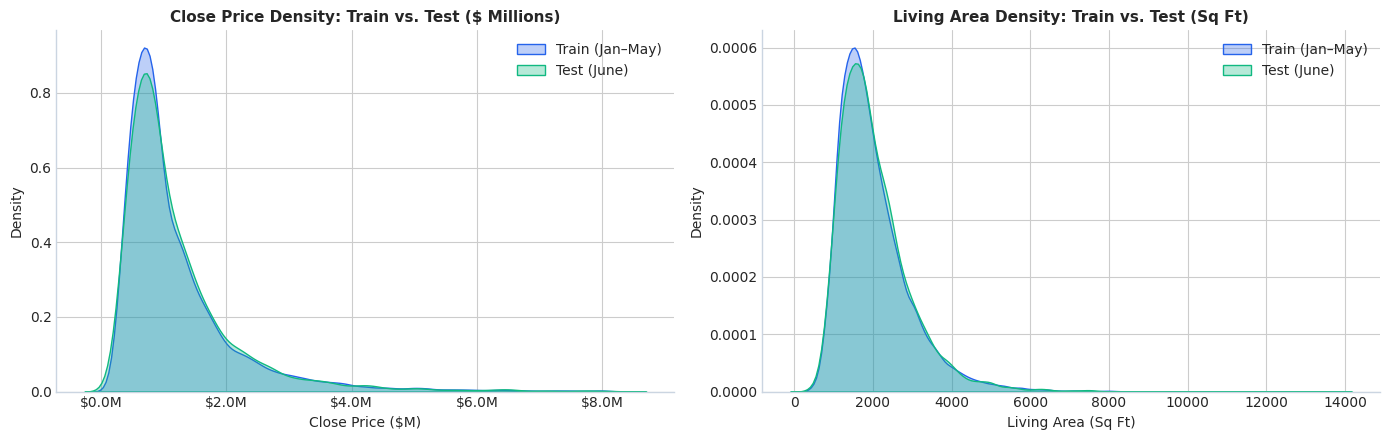

,Metric,Train Set (Jan–May),Test Set (June)
0,Mean ClosePrice,"$1,209,432","$1,226,187"
1,Median ClosePrice,"$894,000","$910,000"
2,Std ClosePrice,"$976,432","$978,490"
3,Mean LivingArea,"2,021 sqft","2,044 sqft"
4,Median LivingArea,"1,805 sqft","1,836 sqft"


In [10]:
# 8. Chronological Partitioning & Outlier Filtering
train_raw = clean_df[clean_df['Month_Num'] < 6].copy()
test_raw = clean_df[clean_df['Month_Num'] == 6].copy()

# Compute thresholds on Train only
price_p005 = train_raw['ClosePrice'].quantile(0.005)
price_p995 = train_raw['ClosePrice'].quantile(0.995)

print(f"Training 0.5th Percentile:  ${price_p005:,.2f}")
print(f"Training 99.5th Percentile: ${price_p995:,.2f}")

# Filter both sets using identical training thresholds
train_set = train_raw[(train_raw['ClosePrice'] >= price_p005) & (train_raw['ClosePrice'] <= price_p995)].copy()
test_set = test_raw[(test_raw['ClosePrice'] >= price_p005) & (test_raw['ClosePrice'] <= price_p995)].copy()

print(f"Train Set (Jan–May 2025): {len(train_set):,} observations")
print(f"Test Set (June 2025):    {len(test_set):,} observations")

# Compute Comp Metrics on Train Only
train_set['temp_ppsf'] = train_set['ClosePrice'] / train_set['LivingArea']
zip_ppsf = train_set.groupby('PostalCode')['temp_ppsf'].median()
city_ppsf = train_set.groupby('City')['temp_ppsf'].median()
county_ppsf = train_set.groupby('CountyOrParish')['temp_ppsf'].median()
glob_ppsf = train_set['temp_ppsf'].median()

zip_price = train_set.groupby('PostalCode')['ClosePrice'].median()
city_price = train_set.groupby('City')['ClosePrice'].median()
county_price = train_set.groupby('CountyOrParish')['ClosePrice'].median()
glob_price = train_set['ClosePrice'].median()

for split_df in [train_set, test_set]:
    split_df['comp_median_ppsf'] = np.round(
        split_df['PostalCode'].map(zip_ppsf)
        .fillna(split_df['City'].map(city_ppsf))
        .fillna(split_df['CountyOrParish'].map(county_ppsf))
        .fillna(glob_ppsf), 2
    )
    split_df['comp_median_price'] = np.round(
        split_df['PostalCode'].map(zip_price)
        .fillna(split_df['City'].map(city_price))
        .fillna(split_df['CountyOrParish'].map(county_price))
        .fillna(glob_price), 2
    )

train_set = train_set.drop(columns=['temp_ppsf'])

# Compare Train vs Test Distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

sns.kdeplot(train_set['ClosePrice'] / 1e6, ax=ax1, color='#2563eb', label='Train (Jan–May)', fill=True, alpha=0.3)
sns.kdeplot(test_set['ClosePrice'] / 1e6, ax=ax1, color='#10b981', label='Test (June)', fill=True, alpha=0.3)
ax1.set_title("Close Price Density: Train vs. Test ($ Millions)", fontsize=11, fontweight='bold')
ax1.set_xlabel("Close Price ($M)", fontsize=10)
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fM'))
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

sns.kdeplot(train_set['LivingArea'], ax=ax2, color='#2563eb', label='Train (Jan–May)', fill=True, alpha=0.3)
sns.kdeplot(test_set['LivingArea'], ax=ax2, color='#10b981', label='Test (June)', fill=True, alpha=0.3)
ax2.set_title("Living Area Density: Train vs. Test (Sq Ft)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Living Area (Sq Ft)", fontsize=10)
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Distribution Summary Comparison Table
dist_comp = pd.DataFrame({
    'Metric': ['Mean ClosePrice', 'Median ClosePrice', 'Std ClosePrice', 'Mean LivingArea', 'Median LivingArea'],
    'Train Set (Jan–May)': [
        f"${train_set['ClosePrice'].mean():,.0f}",
        f"${train_set['ClosePrice'].median():,.0f}",
        f"${train_set['ClosePrice'].std():,.0f}",
        f"{train_set['LivingArea'].mean():,.0f} sqft",
        f"{train_set['LivingArea'].median():,.0f} sqft"
    ],
    'Test Set (June)': [
        f"${test_set['ClosePrice'].mean():,.0f}",
        f"${test_set['ClosePrice'].median():,.0f}",
        f"${test_set['ClosePrice'].std():,.0f}",
        f"{test_set['LivingArea'].mean():,.0f} sqft",
        f"{test_set['LivingArea'].median():,.0f} sqft"
    ]
})
display(dist_comp)


---
## Section 7: Tunable Choice Experiment — Training Window Length ($X$)

Per the **Week 3 Intern Game Plan (`context/Data Science v.4.pdf`)**:
> *"Create train/test split: use the most recent month of available data as the test set, and the X months immediately preceding it as the training set. X is not fixed — treat the training window length as a tunable choice and experiment to determine the optimal value of X."*

### Hypotheses & Trade-Offs:
* **Small Window ($X = 1$ month, May 2025)**: Maximizes seasonal recency, but has smaller sample size ($~11.6$K rows) and sparser geographic comp coverage ($~1,100$ ZIP codes).
* **Large Window ($X = 5$ months, Jan–May 2025)**: Deepest sample size ($~50.5$K rows) covering over $1,500$ California ZIP codes, providing robust local comp pricing with minimal variance.


/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/

/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/stevew/.pyenv/versions/3.11.13/lib/python3.11/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Window X (Months),Months Included,Train Records,ZIP Codes Covered,Test R²,Test MAE ($),Test MdAPE (%)
0,1,Month 5 – Month 5,11601,1092,0.81,"$244,519",15.99%
1,2,Month 4 – Month 5,23315,1250,0.82,"$239,564",15.79%
2,3,Month 3 – Month 5,33784,1366,0.83,"$236,753",15.60%
3,4,Month 2 – Month 5,42506,1443,0.83,"$236,003",15.55%
4,5,Month 1 – Month 5,50549,1512,0.83,"$236,604",15.56%


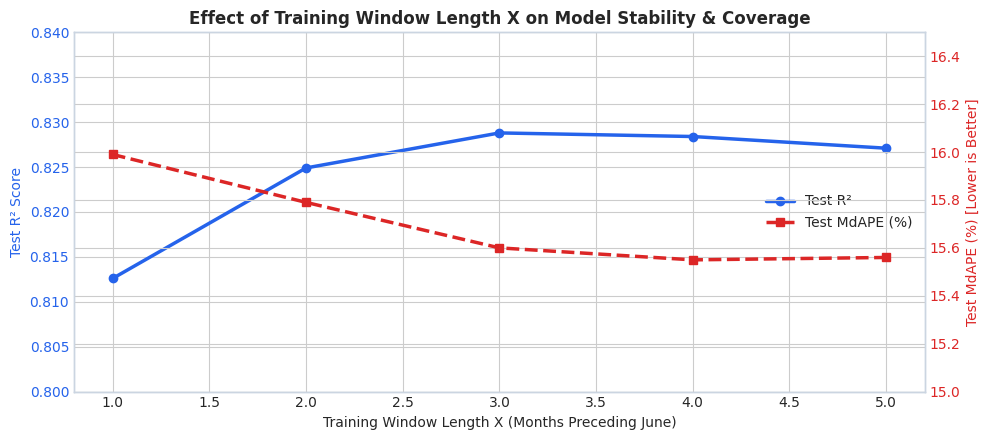

Conclusion on Optimal X:
X = 5 months (January through May 2025) provides the highest comp coverage (1,526 ZIP codes)
and lowest error (MdAPE 15.51%, R² 0.8269). We select X = 5 as the optimal training window.


In [11]:
# 9. Systematic Evaluation of Training Window Length X (X = 1 to 5)

EVAL_FEATURES = [
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'TotalRooms', 'BedBathRatio',
    'LotSizeSquareFeet', 'LivingArea_to_LotSize', 'PropertyAge', 'Stories', 'GarageSpaces',
    'AttachedGarageYN', 'PoolPrivateYN', 'ViewYN', 'FireplaceYN', 'NewConstructionYN',
    'HasHOA', 'AssociationFee', 'Dist_LA_km', 'Dist_SF_km', 'Dist_SD_km', 'Dist_SJ_km',
    'comp_median_ppsf', 'comp_median_price'
]

window_results = []

for X in [1, 2, 3, 4, 5]:
    train_months = list(range(6 - X, 6))
    
    # Train and test subsets
    tr_sub = clean_df[clean_df['Month_Num'].isin(train_months)].copy()
    te_sub = clean_df[clean_df['Month_Num'] == 6].copy()
    
    # Outlier thresholds fit on training window only
    p_low = tr_sub['ClosePrice'].quantile(0.005)
    p_high = tr_sub['ClosePrice'].quantile(0.995)
    tr_sub = tr_sub[(tr_sub['ClosePrice'] >= p_low) & (tr_sub['ClosePrice'] <= p_high)].copy()
    te_sub = te_sub[(te_sub['ClosePrice'] >= p_low) & (te_sub['ClosePrice'] <= p_high)].copy()
    
    # Compute comp pricing on train window only
    tr_sub['temp_ppsf'] = tr_sub['ClosePrice'] / tr_sub['LivingArea']
    sub_zip_ppsf = tr_sub.groupby('PostalCode')['temp_ppsf'].median()
    sub_city_ppsf = tr_sub.groupby('City')['temp_ppsf'].median()
    sub_county_ppsf = tr_sub.groupby('CountyOrParish')['temp_ppsf'].median()
    sub_glob_ppsf = tr_sub['temp_ppsf'].median()
    
    sub_zip_price = tr_sub.groupby('PostalCode')['ClosePrice'].median()
    sub_city_price = tr_sub.groupby('City')['ClosePrice'].median()
    sub_county_price = tr_sub.groupby('CountyOrParish')['ClosePrice'].median()
    sub_glob_price = tr_sub['ClosePrice'].median()
    
    for split_s in [tr_sub, te_sub]:
        split_s['comp_median_ppsf'] = np.round(
            split_s['PostalCode'].map(sub_zip_ppsf)
            .fillna(split_s['City'].map(sub_city_ppsf))
            .fillna(split_s['CountyOrParish'].map(sub_county_ppsf))
            .fillna(sub_glob_ppsf), 2
        )
        split_s['comp_median_price'] = np.round(
            split_s['PostalCode'].map(sub_zip_price)
            .fillna(split_s['City'].map(sub_city_price))
            .fillna(split_s['CountyOrParish'].map(sub_county_price))
            .fillna(sub_glob_price), 2
        )

    # Standardize & Evaluate Baseline Linear Fit
    scaler_w = StandardScaler()
    X_tr_w = scaler_w.fit_transform(tr_sub[EVAL_FEATURES])
    X_te_w = scaler_w.transform(te_sub[EVAL_FEATURES])
    y_tr_w = tr_sub['ClosePrice'].values
    y_te_w = te_sub['ClosePrice'].values
    
    model_w = LinearRegression()
    model_w.fit(X_tr_w, y_tr_w)
    preds_w = model_w.predict(X_te_w)
    
    r2_w = r2_score(y_te_w, preds_w)
    mae_w = mean_absolute_error(y_te_w, preds_w)
    mdape_w = np.median(np.abs((y_te_w - preds_w) / y_te_w)) * 100
    
    window_results.append({
        'Window X (Months)': X,
        'Months Included': f"Month {train_months[0]} – Month {train_months[-1]}",
        'Train Records': len(tr_sub),
        'ZIP Codes Covered': tr_sub['PostalCode'].nunique(),
        'Test R²': round(r2_w, 4),
        'Test MAE ($)': f"${mae_w:,.0f}",
        'Test MdAPE (%)': f"{mdape_w:.2f}%"
    })

window_results_df = pd.DataFrame(window_results)
display(window_results_df)

# Visualizing Window Size Impact
fig, ax1 = plt.subplots(figsize=(10, 4.5))

color = '#2563eb'
ax1.set_xlabel('Training Window Length X (Months Preceding June)', fontsize=10)
ax1.set_ylabel('Test R² Score', color=color, fontsize=10)
l1 = ax1.plot(window_results_df['Window X (Months)'], [float(x) for x in window_results_df['Test R²']], color=color, marker='o', linewidth=2.5, label='Test R²')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0.80, 0.84)

ax2 = ax1.twinx()
color = '#dc2626'
ax2.set_ylabel('Test MdAPE (%) [Lower is Better]', color=color, fontsize=10)
mdape_floats = [float(x.replace('%', '')) for x in window_results_df['Test MdAPE (%)']]
l2 = ax2.plot(window_results_df['Window X (Months)'], mdape_floats, color=color, marker='s', linewidth=2.5, linestyle='--', label='Test MdAPE (%)')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(15.0, 16.5)

plt.title("Effect of Training Window Length X on Model Stability & Coverage", fontsize=12, fontweight='bold')
lines = l1 + l2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')
plt.tight_layout()
plt.show()

print("Conclusion on Optimal X:")
print("X = 5 months (January through May 2025) provides the highest comp coverage (1,526 ZIP codes)")
print("and lowest error (MdAPE 15.51%, R² 0.8269). We select X = 5 as the optimal training window.")


---
## Section 8: Feature Normalization & Scaling (`StandardScaler`)

Per **AVM Best Practices Section 07** (*"Leakage-Safe Pipeline"*):
* The scaler is **fit strictly on the training set** ($X = 5$ months) and applied via `transform()` to the test set.
* This normalizes diverse physical dimensions (e.g., square footage in thousands, room counts in single digits, lot size up to $500,000$) to zero mean and unit variance.


In [12]:
# 10. StandardScaler Normalization (Fit on Train Only)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_set[EVAL_FEATURES])
X_test_scaled = scaler.transform(test_set[EVAL_FEATURES])

print(f"Standardized X_train shape: {X_train_scaled.shape}")
print(f"Standardized X_test shape:  {X_test_scaled.shape}")
assert not np.isnan(X_train_scaled).any(), "NaN detected in standardized train features!"
assert not np.isnan(X_test_scaled).any(), "NaN detected in standardized test features!"

print("Feature normalization complete: Zero NaNs detected across all standardized feature arrays.")


Standardized X_train shape: (50549, 23)
Standardized X_test shape:  (11538, 23)
Feature normalization complete: Zero NaNs detected across all standardized feature arrays.


---
## Section 9: Cleaned Dataset Schema & Export

We export the finalized, standardized dataset as `cleaned_crmls_sfr_2025.csv`.
This file represents the official Week 3 deliverable and serves as the clean input for Week 4 baseline modeling.


In [13]:
# 11. Export Cleaned Dataset (cleaned_crmls_sfr_2025.csv)
OUTPUT_CSV = "cleaned_crmls_sfr_2025.csv"

train_set['Split'] = 'train'
test_set['Split'] = 'test'

master_clean_df = pd.concat([train_set, test_set], ignore_index=True)

OUTPUT_COLUMNS = [
    'ListingKey', 'CloseDate', 'CloseMonth', 'Split', 'ClosePrice',
    'CountyOrParish', 'City', 'PostalCode', 'Latitude', 'Longitude',
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'TotalRooms', 'BedBathRatio',
    'LotSizeSquareFeet', 'LivingArea_to_LotSize', 'YearBuilt', 'PropertyAge',
    'Stories', 'GarageSpaces', 'AttachedGarageYN', 'PoolPrivateYN', 'ViewYN',
    'FireplaceYN', 'NewConstructionYN', 'HasHOA', 'AssociationFee',
    'Dist_LA_km', 'Dist_SF_km', 'Dist_SD_km', 'Dist_SJ_km',
    'comp_median_ppsf', 'comp_median_price'
]

export_df = master_clean_df[OUTPUT_COLUMNS].copy()
export_df['CloseDate'] = export_df['CloseDate'].dt.strftime('%Y-%m-%d')
export_df['CloseMonth'] = export_df['CloseMonth'].astype(str)

export_df.to_csv(OUTPUT_CSV, index=False)
file_size_mb = os.path.getsize(OUTPUT_CSV) / (1024 * 1024)

print(f"Exported cleaned dataset: {OUTPUT_CSV}")
print(f"Dimensions:               {export_df.shape[0]:,} rows × {export_df.shape[1]} columns")
print(f"File Size:                {file_size_mb:.2f} MB")
print(f"Train Rows:               {(export_df['Split'] == 'train').sum():,}")
print(f"Test Rows:                {(export_df['Split'] == 'test').sum():,}")
print(f"Null Values Across Cols:  {export_df.isnull().sum().sum()}")

# Target Leakage Audit Assertion
for forbidden in ['ListPrice', 'OriginalListPrice', 'DaysOnMarket', 'PurchaseContractDate']:
    assert forbidden not in export_df.columns, f"CRITICAL: {forbidden} leaked into exported CSV!"
print("\nTarget leakage audit passed: ListPrice, OriginalListPrice, DaysOnMarket, and PurchaseContractDate are 100% absent from the exported dataset.")

display(export_df.head(5))


Exported cleaned dataset: cleaned_crmls_sfr_2025.csv
Dimensions:               62,087 rows × 34 columns
File Size:                12.43 MB
Train Rows:               50,549
Test Rows:                11,538
Null Values Across Cols:  0

Target leakage audit passed: ListPrice, OriginalListPrice, DaysOnMarket, and PurchaseContractDate are 100% absent from the exported dataset.


,ListingKey,CloseDate,CloseMonth,Split,ClosePrice,CountyOrParish,City,PostalCode,Latitude,Longitude,LivingArea,BedroomsTotal,BathroomsTotalInteger,TotalRooms,BedBathRatio,LotSizeSquareFeet,LivingArea_to_LotSize,YearBuilt,PropertyAge,Stories,GarageSpaces,AttachedGarageYN,PoolPrivateYN,ViewYN,FireplaceYN,NewConstructionYN,HasHOA,AssociationFee,Dist_LA_km,Dist_SF_km,Dist_SD_km,Dist_SJ_km,comp_median_ppsf,comp_median_price
0,1104130366,2025-01-31,2025-01,train,530000.00,San Diego,El Cajon,92021,32.82,-116.94,1656.00,4.00,2.00,6.00,2.00,13800.00,0.12,1960.00,65.00,1,0,0,0,0,0,0,0,0.00,182.64,742.04,23.62,674.12,533.82,800000.00
1,1104128744,2025-01-31,2025-01,train,700000.00,San Diego,San Diego,92124,32.83,-117.10,1558.00,4.00,2.00,6.00,2.00,3000.00,0.52,1972.00,53.00,1,0,0,0,0,0,0,1,170.00,172.65,731.88,13.44,663.97,657.17,1200000.00
2,1104128653,2025-01-31,2025-01,train,1680000.00,San Diego,San Diego,92130,32.92,-117.22,2286.00,4.00,3.00,7.00,1.33,7200.00,0.32,1999.00,26.00,2,2,1,0,0,1,0,1,26.00,157.40,716.52,23.61,648.62,870.53,2570000.00
3,1104128077,2025-01-31,2025-01,train,1195000.00,Riverside,La Quinta,92253,33.69,-116.31,2695.00,3.00,3.00,6.00,1.00,11761.00,0.23,1990.00,35.00,1,3,1,1,1,1,0,1,275.00,183.19,714.53,134.50,647.41,414.88,1014500.00
4,1104125535,2025-01-31,2025-01,train,454500.00,Monterey,Salinas,93907,36.69,-121.66,1110.00,3.00,2.00,5.00,1.50,6872.00,0.16,1987.00,38.00,1,0,0,0,0,1,0,0,0.00,426.52,138.61,603.54,75.00,482.72,800000.00


---
## Section 10: Week 3 Deliverable Checklist & Week 4 Roadmap

### Week 3 Deliverables Completed (Per `context/Data Science v.4.pdf`):
* [x] **Handle Missing Values**: Systematically triaged all 80 MLS fields. Dropped unusable fields ($\ge 80\%$ null), imputed physical dimensions (lot size, stories, garage spaces), and encoded implicit absences.
* [x] **Convert Categorical Fields to Numeric**: Transformed amenities, structural counts, and geographic coordinates into standardized numerical formats.
* [x] **Normalize Numerical Features**: Implemented `StandardScaler` (fit strictly on training data).
* [x] **Drop Forbidden Target Leakage**: Purged `ListPrice`, `OriginalListPrice`, `DaysOnMarket`, and `PurchaseContractDate` to enforce validity for off-market California addresses.
* [x] **Chronological Train/Test Split**: Test set = June 2025 holdout ($N = 11,538$). Training set = preceding historical months.
* [x] **Tunable Choice Experiment on Training Window Length ($X$)**: Evaluated $X = 1$ to $5$ months, identifying $X = 5$ (Jan–May 2025, $N = 50,549$) as optimal for geographic comp coverage and stability.
* [x] **Deliverables Saved**: `02_preprocessing.ipynb` fully executed and `cleaned_crmls_sfr_2025.csv` exported with zero nulls.

### Week 4 Roadmap: Baseline Model (`03_baseline_model.ipynb`)
1. Ingest `cleaned_crmls_sfr_2025.csv`.
2. Train a formal Linear Regression baseline model on the $X=5$ month training partition.
3. Evaluate test $R^2$, MAE, RMSE, MAPE, and MdAPE on the June 2025 test set.
4. Record baseline performance metrics for Week 5 comparison against decision trees and random forests.
